# US Births Data Analysis
## Comprehensive Analysis Pipeline

This notebook demonstrates the complete analysis pipeline for US births data, similar to the wind farm analysis.

In [3]:
# Standard imports
from datasets import load_dataset
import duckdb as ddb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime

# Import the US births analysis module
import utilities.us_births_analysis as births

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 7)

print("✓ All imports successful")

✓ All imports successful


In [5]:
# Load dataset
ds = load_dataset("thuml/UTSD", "UTSD-1G")
df = pd.DataFrame(ds['train'])

# Connect to DuckDB
con = ddb.connect()

print(f"Dataset loaded: {len(df)} time series")

Resolving data files:   0%|          | 0/320 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Dataset loaded: 68679 time series


In [6]:
# Filter for US births data
us_births_df = con.execute("""
    SELECT * FROM df WHERE item_id LIKE '%birth%';
""").fetch_df()

print(f"Found {len(us_births_df)} US births time series")
us_births_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Found 1 US births time series


,item_id,start,end,freq,target
0,Nature_us_births_dataset_0_0,1969-01-01T00:00:00.000000000,1988-12-31T00:00:00.000000000,D,"[8486.0, 9002.0, 9542.0, 8960.0, 8390.0, 9560...."


## 1. Complete Analysis Pipeline

Run the complete analysis pipeline to get an overview of the data.

In [ ]:
# Get the first row (should be the only one)
row = us_births_df.iloc[0]

# Run complete analysis
results = births.analyze_births_data(row)

# Extract results
births_df = results['births_df']
monthly_stats = results['monthly_stats']
yearly_stats = results['yearly_stats']
interval_info = results['interval_info']

US BIRTHS DATA ANALYSIS

Step 1: Detecting time interval...

Time Series Information:
  Start: 1969-01-01 00:00:00
  End: 1988-12-31 00:00:00
  Duration: 7304 days 00:00:00
  Data points: 7,305
  Interval: 1.0d
  Frequency (pandas): 1D
  Frequency (dataset): 'D'

Step 2: Expanding time series...
  Created DataFrame with 7,305 rows

Step 3: Calculating statistics...
  Generated monthly statistics for 240 months
  Generated yearly statistics for 20 years

Overall Statistics:
  Mean births/day: 9648.94
  Median births/day: 9622.00
  Std dev: 1127.32
  Min births/day: 6675
  Max births/day: 12851
  Total births: 70,485,508

Day of Week Analysis:
  Monday: 9944 avg births
  Tuesday: 10368 avg births
  Wednesday: 10089 avg births
  Thursday: 9995 avg births
  Friday: 10147 avg births
  Saturday: 8708 avg births
  Sunday: 8290 avg births

Weekday vs Weekend:
  Weekday average: 10109
  Weekend average: 8500
  Difference: 1609 (18.9%)

Monthly Patterns:
  Highest: September (10343 avg births)
 

## 2. Full Time Series Visualization

Plot the complete time series of daily births.

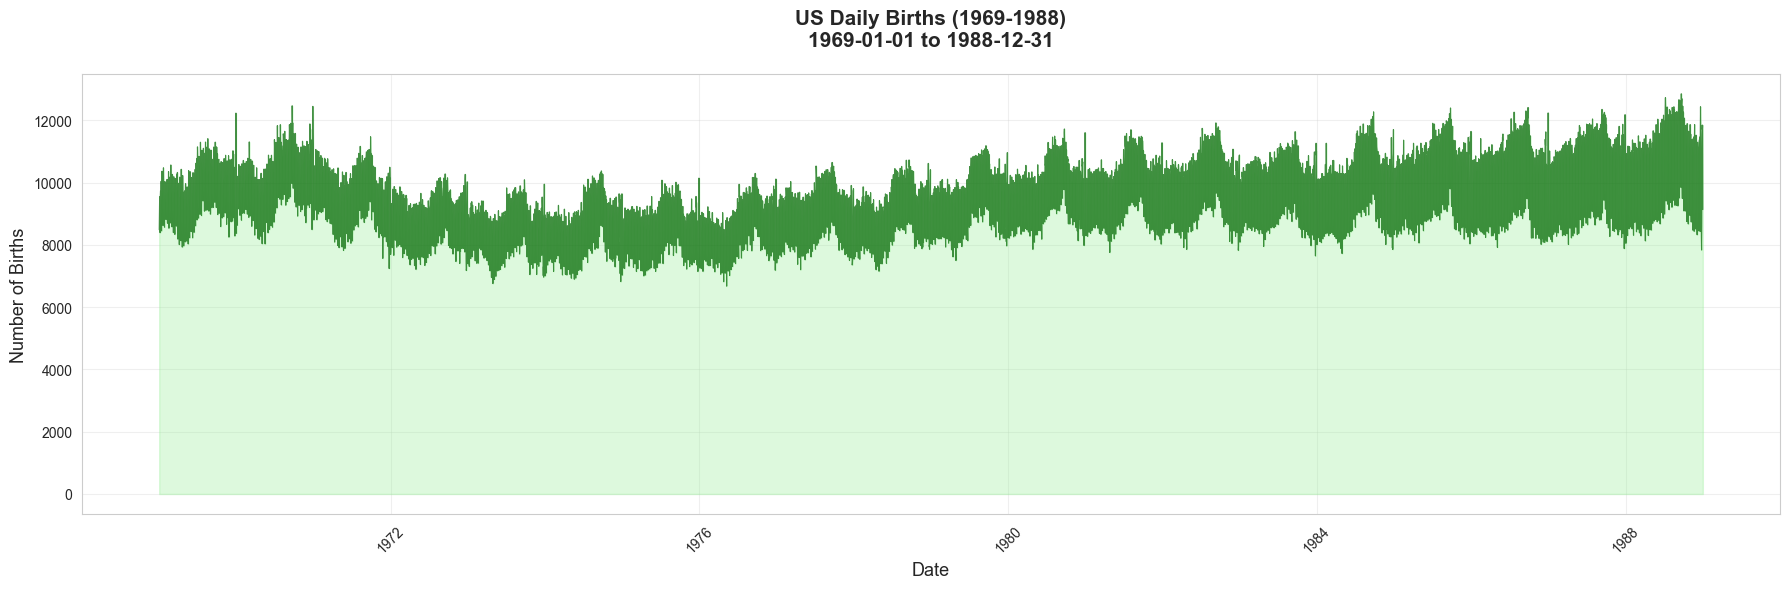

In [ ]:
fig = births.plot_full_timeseries(births_df, title="US Daily Births (1969-1988)")
plt.show()

## 3. Monthly Statistics

Analyze monthly trends and total births per month.

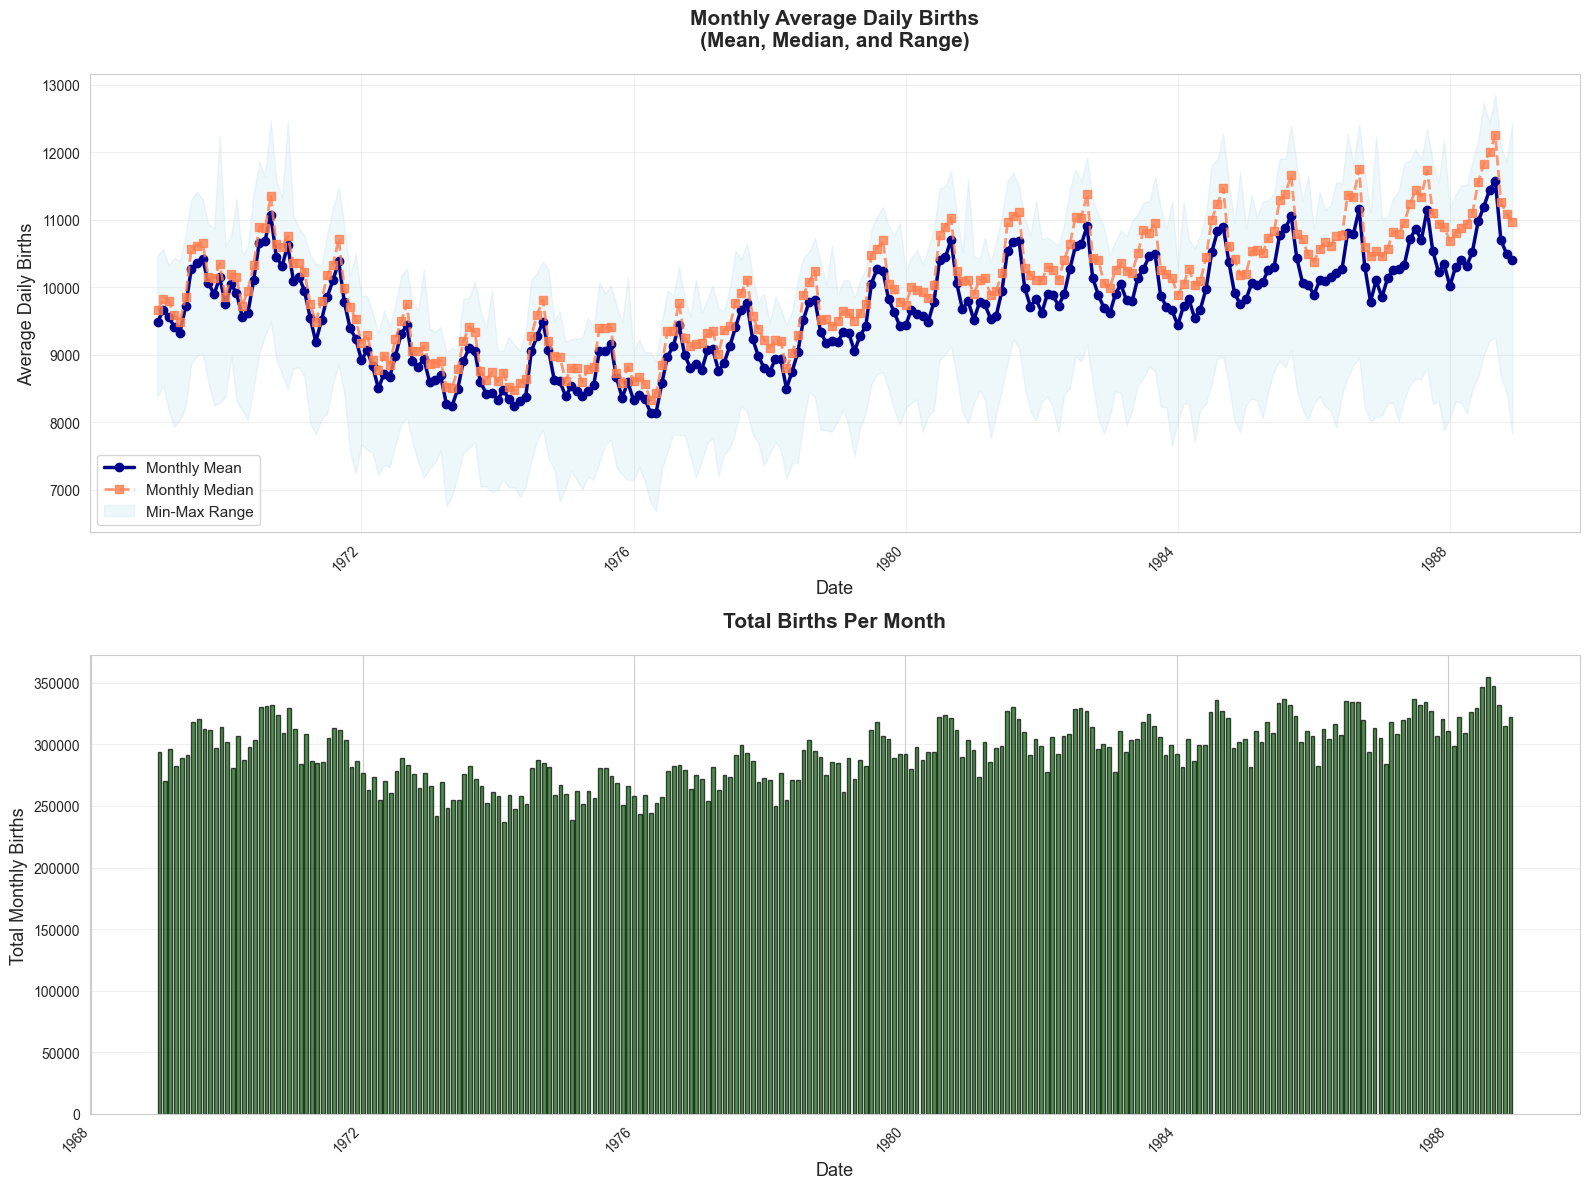

In [ ]:
fig = births.plot_monthly_statistics(monthly_stats)
plt.show()

## 4. Yearly Trends

Examine how births have changed over the years.

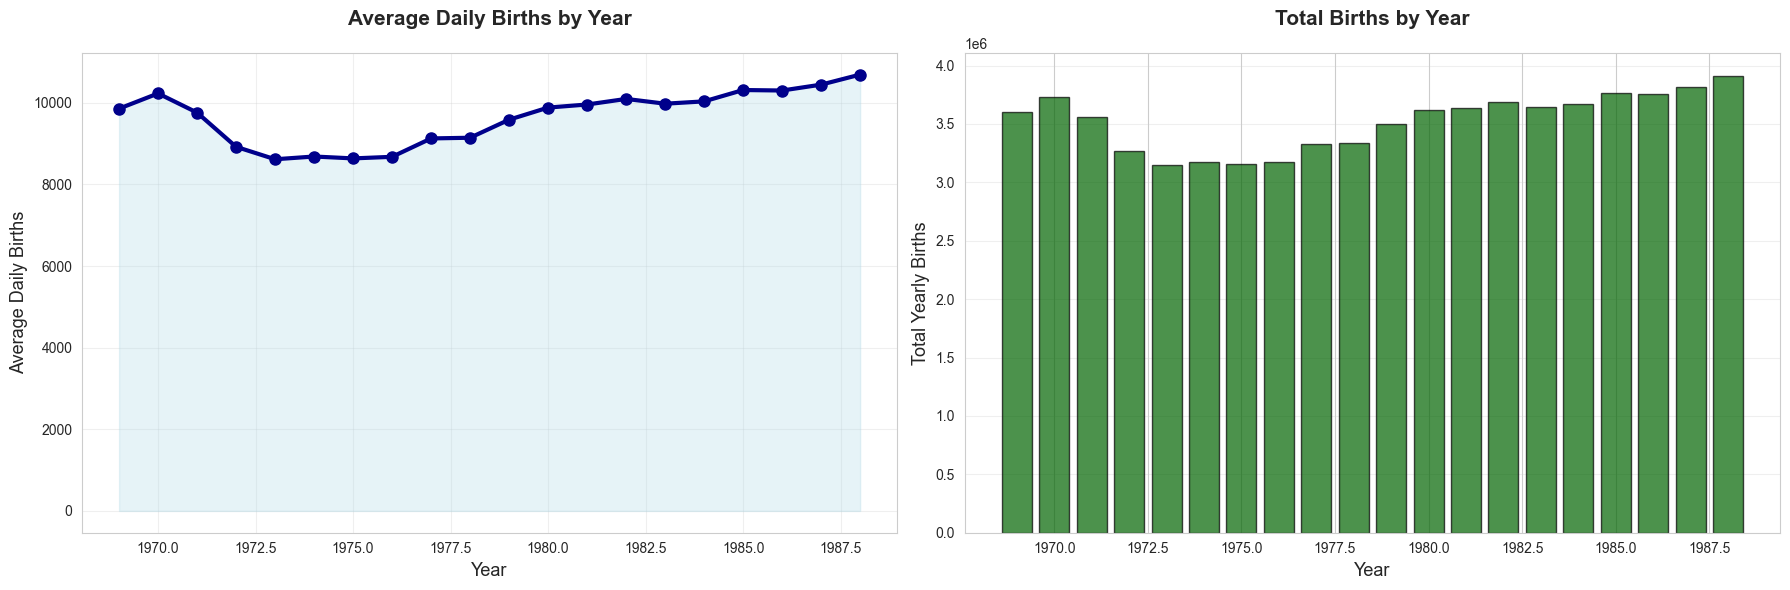

In [ ]:
fig = births.plot_yearly_trends(yearly_stats)
plt.show()

## 5. Day of Week Patterns

Analyze births by day of the week to identify weekday vs weekend patterns.

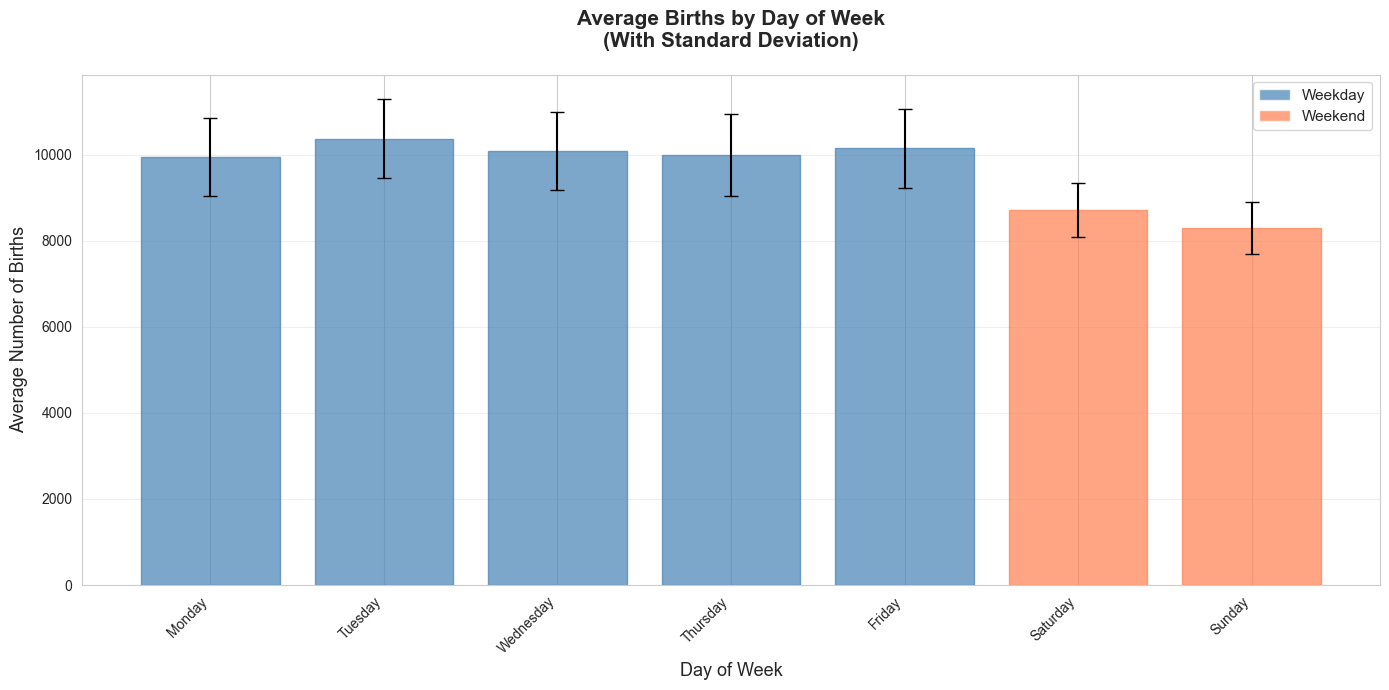

In [ ]:
fig = births.plot_day_of_week_patterns(births_df)
plt.show()

## 6. Seasonal Patterns

Examine seasonal patterns by month of the year.

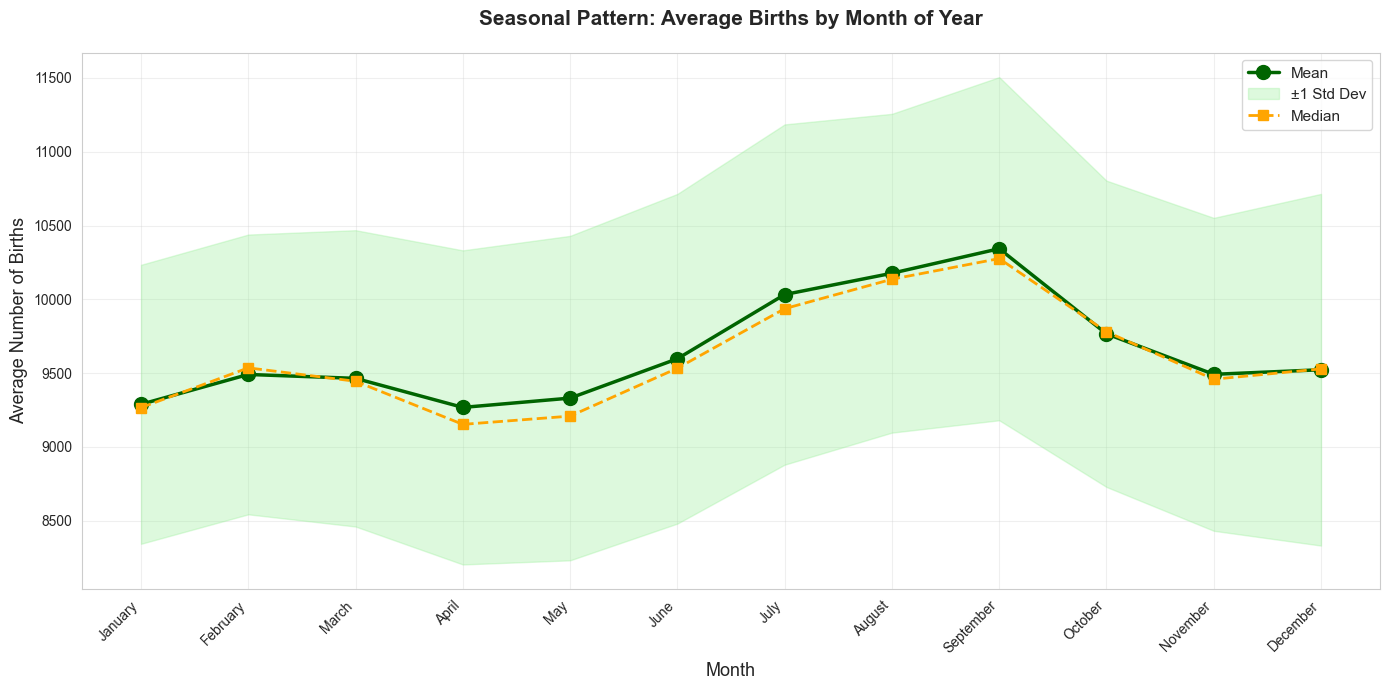

In [ ]:
fig = births.plot_monthly_seasonal_patterns(births_df)
plt.show()

## 7. Births Heatmap

Create a heatmap showing births by year and month.

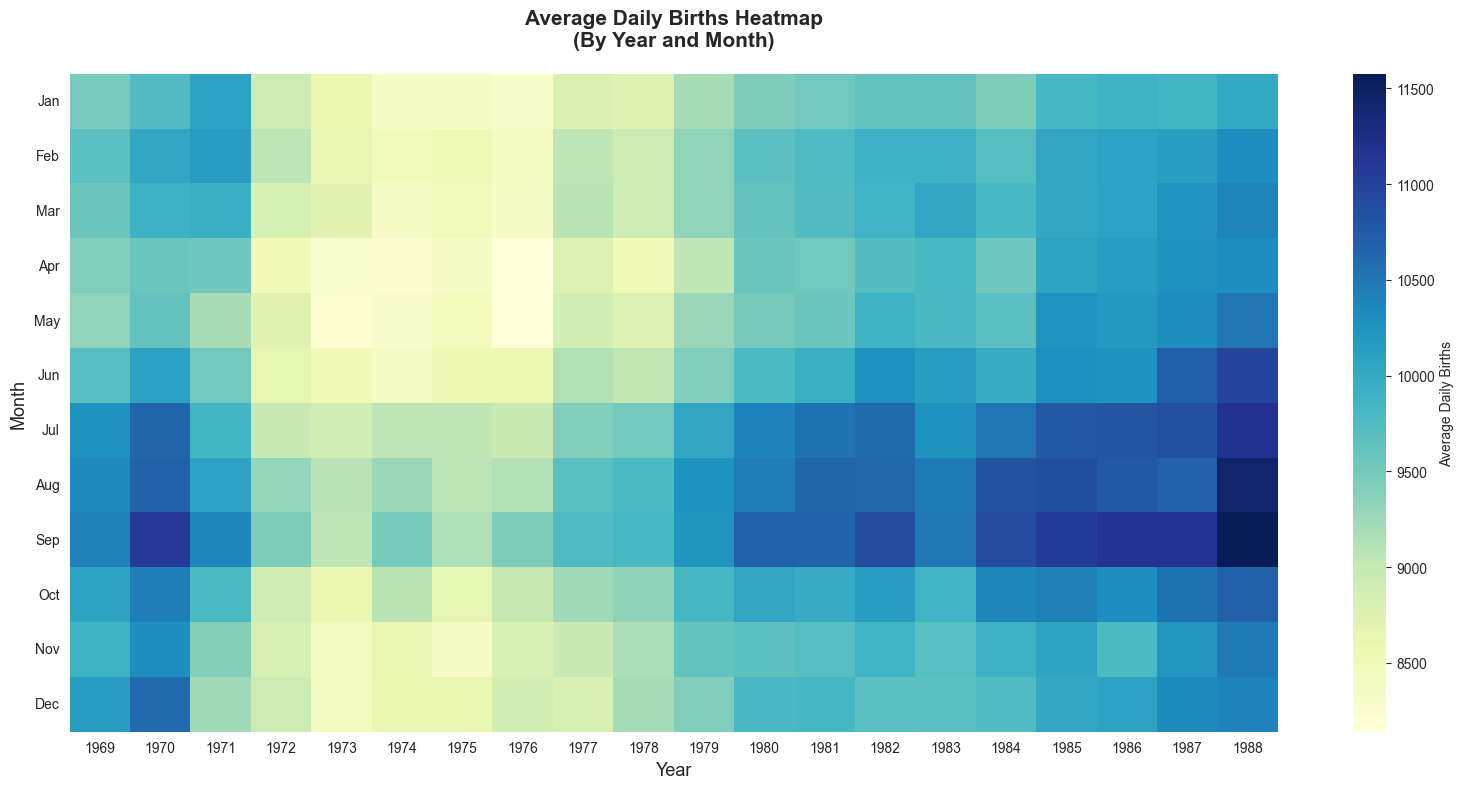

In [ ]:
fig = births.plot_births_heatmap(births_df)
plt.show()

## 8. Weekday vs Weekend Comparison

Compare birth distributions on weekdays versus weekends.

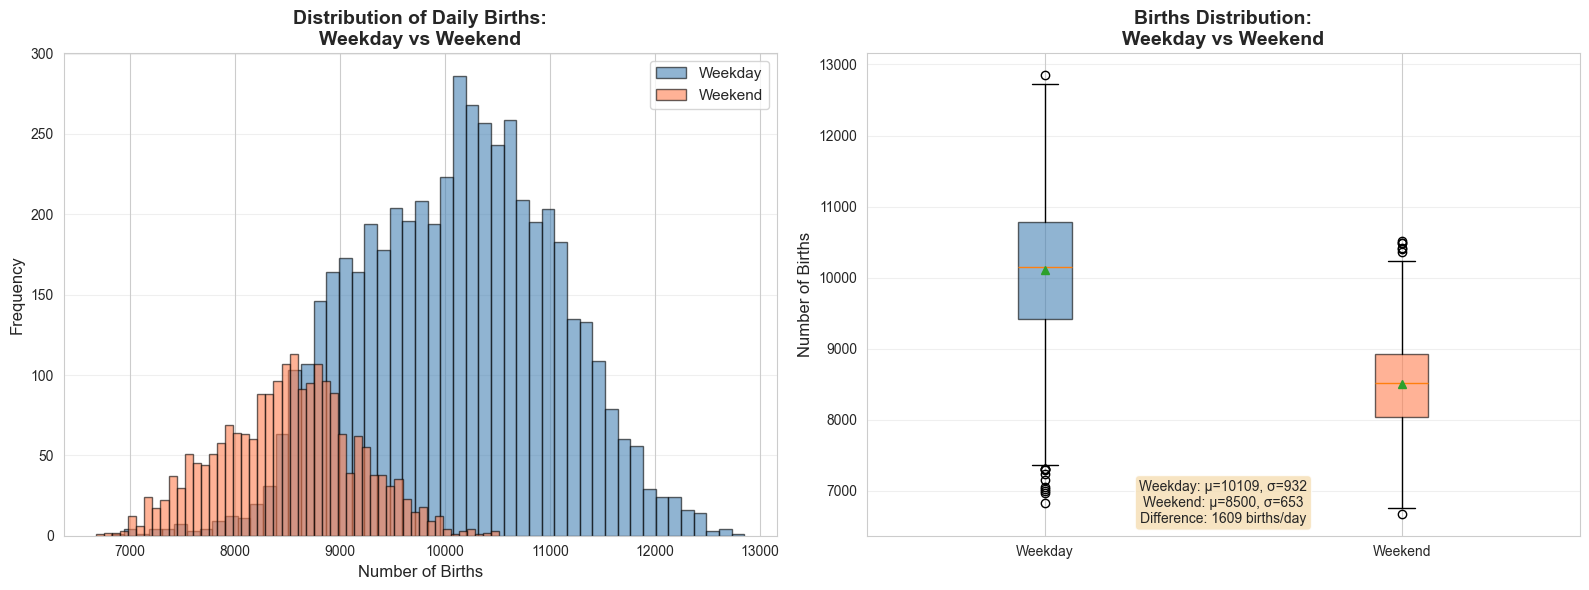

In [ ]:
fig = births.plot_weekday_weekend_comparison(births_df)
plt.show()

## 9. Multi-Year Comparison

Compare birth patterns across different years.

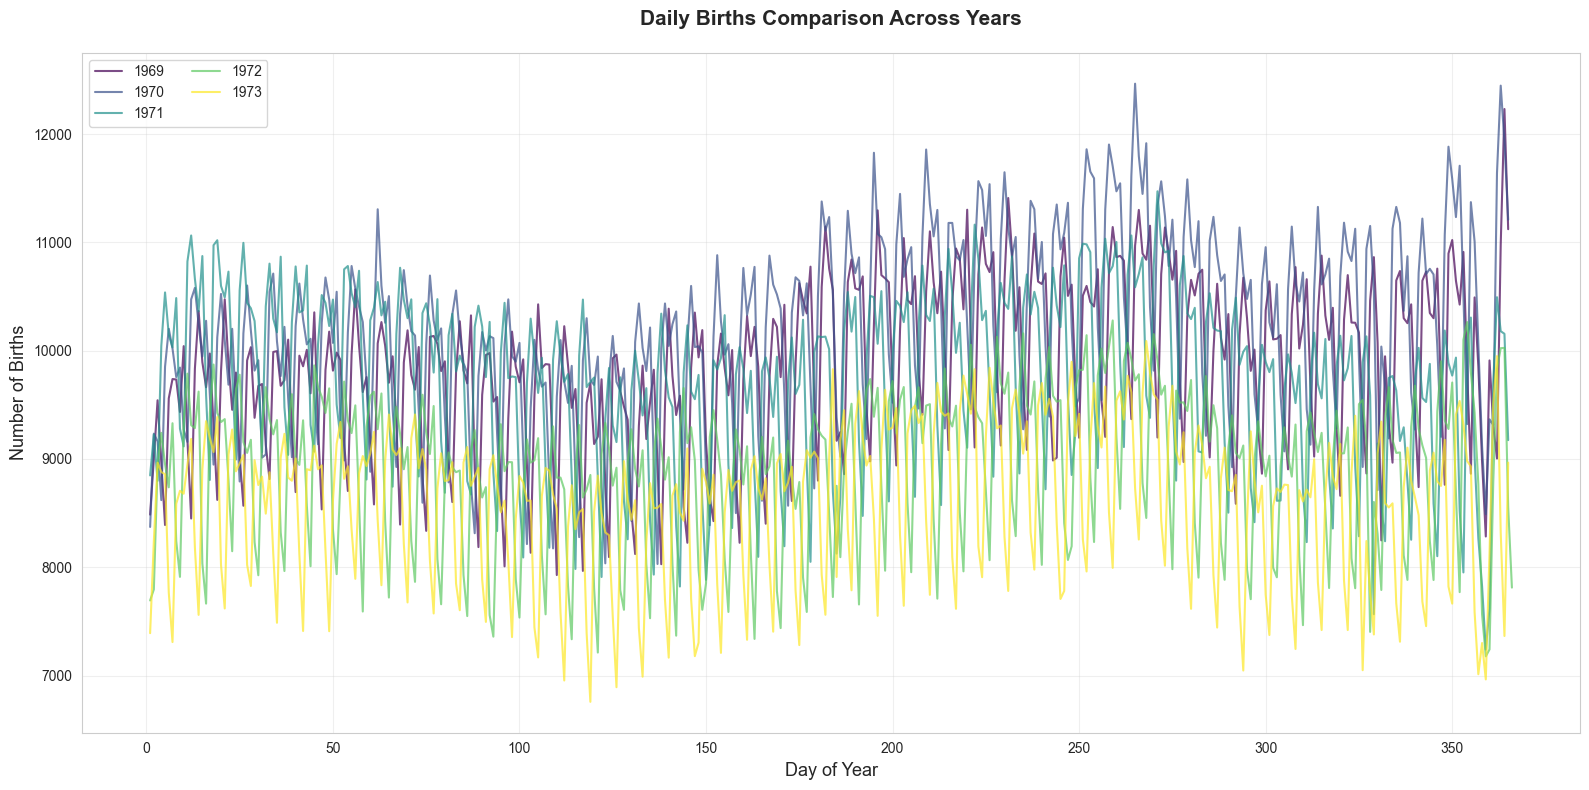

In [ ]:
# Compare first 5 years
years_to_compare = sorted(births_df['year'].unique())[:5]
fig = births.plot_multi_year_comparison(births_df, years=years_to_compare)
plt.show()

## 10. Custom Analysis

Perform custom analysis on the expanded data.

In [ ]:
# Example: Find days with highest and lowest births
print("Days with highest births:")
print(births_df.nlargest(5, 'births')[['datetime', 'births', 'dayofweek_name']])

print("\nDays with lowest births:")
print(births_df.nsmallest(5, 'births')[['datetime', 'births', 'dayofweek_name']])

Days with highest births:
       datetime   births dayofweek_name
7202 1988-09-20  12851.0        Tuesday
7127 1988-07-07  12727.0       Thursday
7205 1988-09-23  12694.0         Friday
7191 1988-09-09  12661.0         Friday
7198 1988-09-16  12620.0         Friday

Days with lowest births:
       datetime  births dayofweek_name
2685 1976-05-09  6675.0         Sunday
1579 1973-04-29  6757.0         Sunday
2671 1976-04-25  6817.0         Sunday
2184 1974-12-25  6820.0      Wednesday
1586 1973-05-06  6892.0         Sunday


In [ ]:
# Calculate year-over-year growth
yearly_stats['yoy_change'] = yearly_stats['sum'].pct_change() * 100

print("Year-over-Year Growth Rate:")
print(yearly_stats[['year', 'sum', 'yoy_change']])

Year-over-Year Growth Rate:
    year        sum  yoy_change
0   1969  3598578.0         NaN
1   1970  3734606.0    3.780049
2   1971  3563074.0   -4.593041
3   1972  3265863.0   -8.341421
4   1973  3145670.0   -3.680283
5   1974  3170306.0    0.783172
6   1975  3153366.0   -0.534333
7   1976  3176266.0    0.726208
8   1977  3332048.0    4.904564
9   1978  3338197.0    0.184541
10  1979  3499737.0    4.839139
11  1980  3617948.0    3.377711
12  1981  3635480.0    0.484584
13  1982  3685374.0    1.372418
14  1983  3642731.0   -1.157087
15  1984  3673531.0    0.845519
16  1985  3765054.0    2.491418
17  1986  3760682.0   -0.116121
18  1987  3813211.0    1.396795
19  1988  3913786.0    2.637541


## Summary

This analysis covers:
- **Time Series Overview**: Full visualization of daily births
- **Monthly Trends**: Average and total births per month
- **Yearly Trends**: Long-term changes in birth rates
- **Day of Week Patterns**: Differences between weekdays and weekends
- **Seasonal Patterns**: Monthly variations throughout the year
- **Heatmaps**: Visual representation of births by year and month
- **Distribution Analysis**: Comparing weekday vs weekend births
- **Multi-Year Comparison**: Patterns across different years

The module provides comprehensive tools for analyzing US births data similar to the wind farm analysis!